# MSM analysis

In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from deeptime.markov import TransitionCountEstimator
from deeptime.markov.msm import MaximumLikelihoodMSM

from matplotlib import color_sequences
macro_color_sequence = color_sequences['Paired']

n_macro = 6
timelag_macro = 1000 # validated with the CK test, see notebook step_3_msm_construction.ipynb

---
# Thermodynamics questions

- equilibrium populations and free energy landscape
- structural caracterization of metastable states: fraction of native contacts, RMSD to crystal, radius of gyration
- representative conformations: visualization with PyMol

In [2]:
macro_traj = np.load(f"intermediate_outputs/traj_pcca_{n_macro}_assignments.npy")
pca_traj = np.load("intermediate_outputs/mindists2_pca_5.npz")['arr_0']


Q_timeseries = np.load("intermediate_outputs/Q_timeseries.npy")
RMSD_timeseries = np.load("intermediate_outputs/RMSD_crystal_nm.npy")


MoSAIC_dict = {
    1 : [(3,14), (3, 13), (6,14), (5, 14)],
    2: [(7, 12), (7, 13), (6,12), (7,11), (6, 11), (6, 17)],
    3: [(12,17), (12,16), (12,20), (13, 17)],
    4: [(18,25), (17,25), (20, 25)],
    5: [(24, 28), (20, 28), (25, 29)],
    6: [(29,35), (29,34), (30,35), (29,33)],
    7: [(10,34), (9,32), (10,29)]
}


def cluster_idx(contact_tuple):
    idx = None
    for i in MoSAIC_dict.keys():
        if contact_tuple in MoSAIC_dict[i]:
            idx = i
            continue
    if idx == None:
        idx = 8
    return idx


contacts = [tuple(x) for x in np.loadtxt(
            "data/hp35.mindists2.ndx",
            comments="#",
            usecols=(0, 1),
            dtype=int
        )
    ]

# reconstruct cluster 8:
contacts_cluster_8 = [contact for contact in contacts if cluster_idx(contact) == 8]
MoSAIC_dict[8] = contacts_cluster_8

contacts_each_cluster = {id: len(contacts) for id, contacts in MoSAIC_dict.items()}


subsets = ['MoSAIC1', 'MoSAIC2', 'MoSAIC3', 'MoSAIC4', 'MoSAIC5', 'MoSAIC6', 'MoSAIC7', 'MoSAIC8']
filenames = [f"intermediate_outputs/totdist_timeseries_{subset}.npy" for subset in subsets]

MoSAIC_totdist_timeseries = [np.load(filename) for filename in filenames]
MoSAIC_totdist_timeseries = [MoSAIC_totdist_timeseries[i] / contacts_each_cluster[i+1] for i in range(len(MoSAIC_totdist_timeseries))]
MoSAIC_totdist_timeseries = np.array(MoSAIC_totdist_timeseries)

# MoSAIC colors
## DO NOT CHANGE THESE COLORS
# they are the same as used in the pymol script


MoSAIC_colors = [
[1.00, 0.15, 0.15],
[0.10, 0.35, 1.00],
[0.10, 0.75, 0.20],
[1.00, 0.55, 0.00],
[0.65, 0.20, 0.90],
[0.00, 0.75, 0.75],
[0.95, 0.85, 0.10],
"grey"
]

Re-index macrostates by increasing fraction of native contacts

In [3]:
median_Q_per_macrostate = []
for id in range(n_macro):
    frames = Q_timeseries[macro_traj == id]
    median_Q_per_macrostate.append(np.median(frames))

# Renumber macrostates by median Q
sorted_indices = np.argsort(median_Q_per_macrostate)

dict = {old: new for new, old in enumerate(sorted_indices)}
macro_traj = np.array([dict[old] for old in macro_traj])

#### Compute statistics per macrostate (1- Q, RMSD) 

In [4]:
def make_violin_plot(ax, macro_traj, observable_traj, n_macro):


    # Collect observable values for each macrostate
    data = [
        observable_traj[macro_traj == i]
        for i in range(n_macro)
    ]
    populations = np.bincount(macro_traj) / len(macro_traj)

    vp = ax.violinplot(
        data,
        positions=np.arange(n_macro),
        widths=0.2 + populations / populations.max(),
        showmeans=True,
        showmedians=True,
        showextrema=False,
    )

    # Color violins
    for body, color in zip(vp['bodies'], macro_color_sequence[:n_macro]):
        body.set_facecolor(color)
        body.set_edgecolor('black')
        body.set_alpha(0.7)

    # Style mean/median lines
    vp['cmeans'].set_color('black')
    vp['cmedians'].set_color('white')
    vp['cmedians'].set_linewidth(2)

    ax.set_xticks(np.arange(n_macro))
    ax.set_xticklabels([f"S{i}" for i in range(n_macro)])
    ax.set_xlabel("Macrostate")
    

    return ax, vp

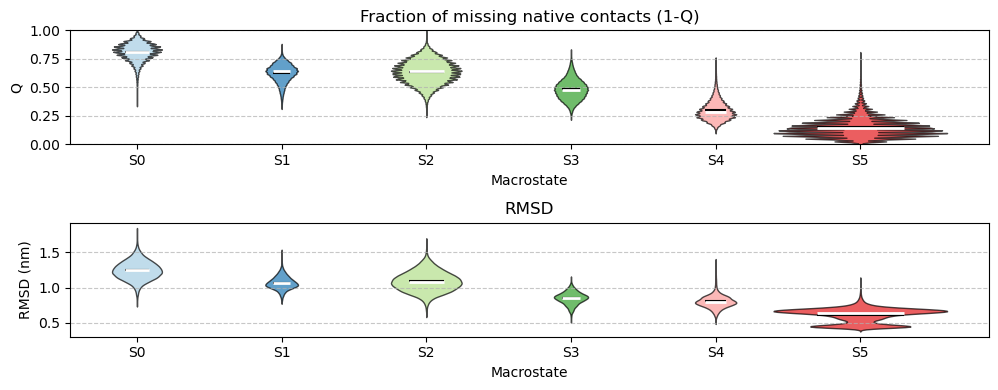

In [5]:
fig, axs = plt.subplots(nrows = 2, ncols = 1, figsize=(10, 4))


ax = axs[0]
ax, vp = make_violin_plot(ax, macro_traj, 1- Q_timeseries, n_macro)
ax.set_title("Fraction of missing native contacts (1-Q)")
ax.set_ylim(0, 1)
ax.set_ylabel("Q")
ax.grid(axis='y', linestyle='--', alpha=0.7)


ax = axs[1]
ax, vp = make_violin_plot(ax, macro_traj, RMSD_timeseries, n_macro)
ax.set_title("RMSD")
ax.set_ylabel("RMSD (nm)")
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

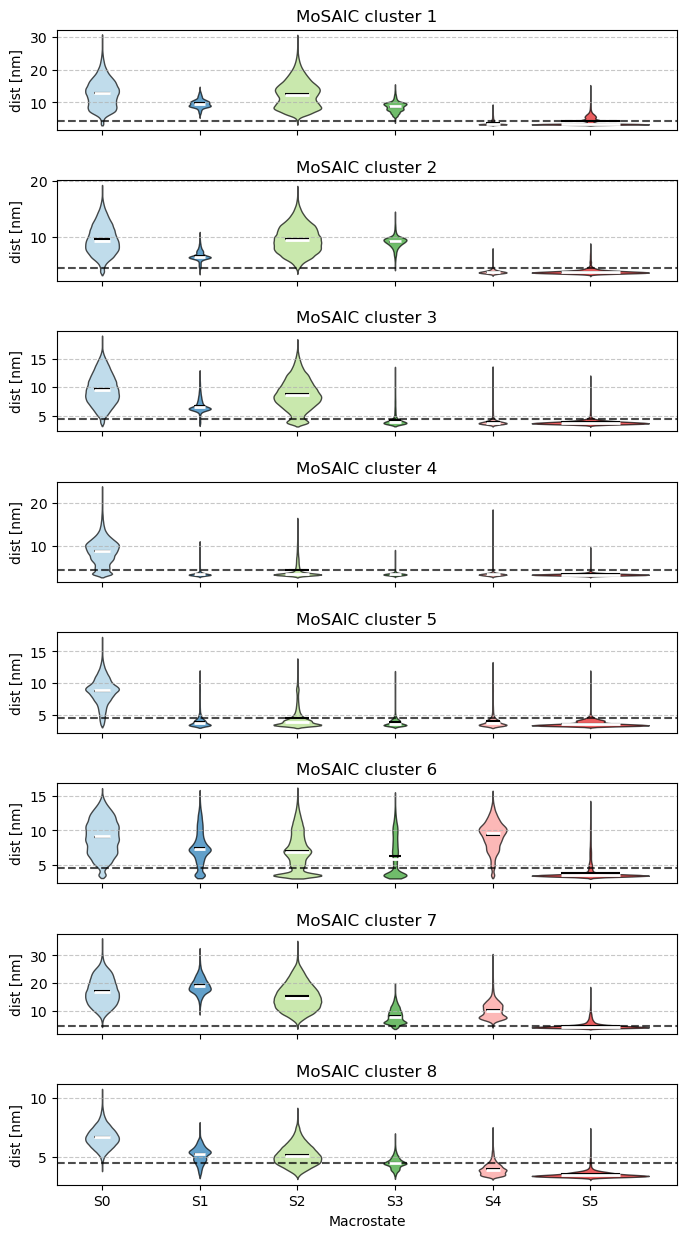

In [41]:
fig, axs = plt.subplots(nrows=len(MoSAIC_colors), ncols=1, figsize=( len(MoSAIC_colors), 15))
for i, series in enumerate(MoSAIC_totdist_timeseries):
    ax = axs[i]
    ax.axhline(4.5, color='black', linestyle='--', alpha=0.7,  label= "contact formed")
    ax, vp = make_violin_plot(ax, macro_traj, series, n_macro)
    ax.set_title(f"MoSAIC cluster {i+1}")
    ax.set_ylabel("dist [nm]")
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    if i < len(MoSAIC_totdist_timeseries) - 1:
        ax.set_xticklabels([]) 
        ax.set_xlabel("")

plt.subplots_adjust(hspace=0.5)
plt.show()

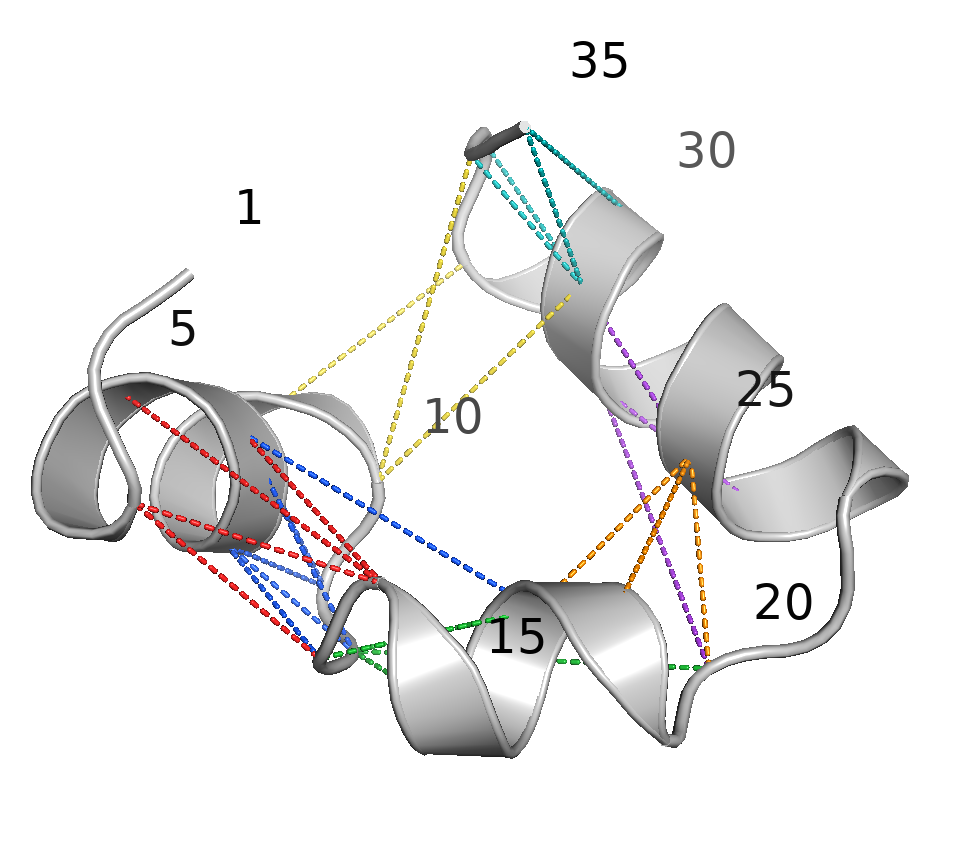

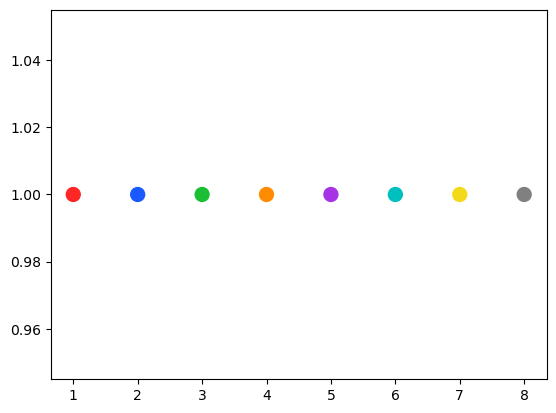

In [7]:
from IPython import display
plt.scatter(range(1, len(MoSAIC_colors)+ 1), np.ones(len(MoSAIC_colors)), s = 100, color = MoSAIC_colors)
display.Image("pymol_io/contacts1.png", width = 300)

**Comments**

- The two states that are most folded, i.e. S5 and S4, mostly appear to differ by the orientation of the C terminus (MoSAIC clusters 6 and 7)
- MoSAIC cluster 8, which consists mostly of helix-stabilizing contacts, appears to correlate very well to the scalar folding coordinate 1-Q. Indeed, the macrostates, that where ordered by increasing median Q, keep the same ordering as far as only Q of cluster 8 is considered.

### Representative structures for PyMOL visualization

In [8]:
microstate_traj = np.load("intermediate_outputs/kmeans_results.npz")['traj']

macro_to_micro = {}

for macro_id in range(n_macro):
    microstates_in_macro, counts = np.unique(microstate_traj[macro_traj == macro_id], return_counts=True)
    sorting_indices = np.argsort(counts)[::-1]
    microstates_in_macro = microstates_in_macro[sorting_indices]
    macro_to_micro[macro_id] = microstates_in_macro

most_probable_microstates = [microstates[0] for microstates in macro_to_micro.values()]

frame_sets = [
    np.where(microstate_traj == i)[0][:5]
    for i in most_probable_microstates
]

In [9]:
out_prefixs = [f"state{i}_pcca{n_macro}" for i in range(n_macro)]

In [10]:
import subprocess

for i, frames in enumerate(frame_sets):

    out_prefix = out_prefixs[i]

    cmd = [
        "python",
        "reconstruct_backbone.py",
        "--data-folder", "./data",
        "--out-prefix", out_prefix,
        "--out-folder", "backbone_reconstructions",
        "--frames",
        *map(str, frames),
    ]

    subprocess.run(cmd, check=True)

Loaded dihedrals: (1526041, 66)
Selected frames: 5
First selected indices: [409 632 653 655 657]
phi_series: (5, 33)
psi_series: (5, 33)
Wrote: backbone_reconstructions/state0_pcca6/state0_pcca6.pdb
Wrote: backbone_reconstructions/state0_pcca6/state0_pcca6.dcd
Wrote: backbone_reconstructions/state0_pcca6/state0_pcca6_selected_frames.txt


Reconstructing backbone: 100%|██████████| 5/5 [00:00<00:00, 225.89it/s]


Loaded dihedrals: (1526041, 66)
Selected frames: 5
First selected indices: [1768 1769 2161 2162 6401]
phi_series: (5, 33)
psi_series: (5, 33)
Wrote: backbone_reconstructions/state1_pcca6/state1_pcca6.pdb
Wrote: backbone_reconstructions/state1_pcca6/state1_pcca6.dcd
Wrote: backbone_reconstructions/state1_pcca6/state1_pcca6_selected_frames.txt


Reconstructing backbone: 100%|██████████| 5/5 [00:00<00:00, 223.56it/s]


Loaded dihedrals: (1526041, 66)
Selected frames: 5
First selected indices: [1491 1500 1501 1511 1519]
phi_series: (5, 33)
psi_series: (5, 33)
Wrote: backbone_reconstructions/state2_pcca6/state2_pcca6.pdb
Wrote: backbone_reconstructions/state2_pcca6/state2_pcca6.dcd
Wrote: backbone_reconstructions/state2_pcca6/state2_pcca6_selected_frames.txt


...

Reconstructing backbone: 100%|██████████| 5/5 [00:00<00:00, 180.17it/s]


Loaded dihedrals: (1526041, 66)
Selected frames: 5
First selected indices: [58352 58353 58408 58414 58415]
phi_series: (5, 33)
psi_series: (5, 33)
Wrote: backbone_reconstructions/state4_pcca6/state4_pcca6.pdb
Wrote: backbone_reconstructions/state4_pcca6/state4_pcca6.dcd
Wrote: backbone_reconstructions/state4_pcca6/state4_pcca6_selected_frames.txt


Reconstructing backbone: 100%|██████████| 5/5 [00:00<00:00, 233.24it/s]


Loaded dihedrals: (1526041, 66)
Selected frames: 5
First selected indices: [59036 59068 59073 59076 59080]
phi_series: (5, 33)
psi_series: (5, 33)
Wrote: backbone_reconstructions/state5_pcca6/state5_pcca6.pdb
Wrote: backbone_reconstructions/state5_pcca6/state5_pcca6.dcd
Wrote: backbone_reconstructions/state5_pcca6/state5_pcca6_selected_frames.txt


Reconstructing backbone: 100%|██████████| 5/5 [00:00<00:00, 212.71it/s]


# A possibility: 
train a supervised model to predict macrostate assignation from pdb/dihedrals/contacts -> understand what are the key coordinates that determine the assigned macrostate -> the key coordinates of the folding process

---
# Dynamics questions

- mean first passage times, in particular: unfolded->folded predicted timescale
- forward committor
- reactive fluxes and dominant pathways

In [11]:
estimator_counts = TransitionCountEstimator(
    lagtime=int(timelag_macro),
    count_mode="sliding-effective"
)
macro_counts = estimator_counts.fit(macro_traj).fetch_model()

print("Weakly connected sets:", macro_counts.connected_sets(directed=False))
print("Strongly connected sets:", macro_counts.connected_sets(directed=True))


estimator_transition = MaximumLikelihoodMSM(
    reversible=True,
    stationary_distribution_constraint=None
)
macro_msm = estimator_transition.fit(macro_counts).fetch_model()

Weakly connected sets: [array([0, 1, 2, 3, 4, 5])]
Strongly connected sets: [array([0, 1, 2, 3, 4, 5])]


In [12]:
print("Self-transition probabilities:", macro_msm.transition_matrix.diagonal())

Self-transition probabilities: [0.53020692 0.48125402 0.61733039 0.23280895 0.11471912 0.89594444]


In [13]:
def plot_msm_network(
    T,
    ax=None,
    state_colors=None,
    pi=None,
    labels=None,
    top_k_per_state=2,
    min_prob=0.02,
    node_size_range=(800, 3500),
    edge_width_range=(1.0, 6.0),
    self_edges=False,
    seed=0,
):
    T = np.asarray(T, dtype=float)
    n = T.shape[0]

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    if labels is None:
        labels = {i: str(i) for i in range(n)}
    else:
        labels = {i: str(labels[i]) for i in range(n)}

    if state_colors is None:
        state_colors = ["lightgrey"] * n

    if pi is None:
        # left stationary distribution for row-stochastic T
        w, v = np.linalg.eig(T.T)
        idx = np.argmin(np.abs(w - 1))
        pi = np.real(v[:, idx])
        pi = np.abs(pi)
        pi = pi / pi.sum()

    # -----------------------------
    # Full graph for layout
    # -----------------------------
    G_full = nx.from_numpy_array(T, create_using=nx.DiGraph())

    pos = nx.spring_layout(
        G_full,
        weight="weight",
        k=5,
        seed=seed
    )

    # -----------------------------
    # Filter edges for plotting
    # -----------------------------
    G_plot = nx.DiGraph()
    G_plot.add_nodes_from(range(n))

    for i in range(n):
        probs = T[i].copy()

        if not self_edges:
            probs[i] = 0.0

        candidates = np.where(probs >= min_prob)[0]

        if len(candidates) > 0:
            strongest = candidates[np.argsort(probs[candidates])[-top_k_per_state:]]

            for j in strongest:
                G_plot.add_edge(i, j, weight=T[i, j])

    # -----------------------------
    # Node sizes
    # -----------------------------
    smin, smax = node_size_range
    if np.max(pi) > np.min(pi):
        node_sizes = smin + (pi - pi.min()) / (pi.max() - pi.min()) * (smax - smin)
    else:
        node_sizes = np.full(n, 0.5 * (smin + smax))

    # -----------------------------
    # Edge widths
    # -----------------------------
    edges = list(G_plot.edges())
    weights = np.array([G_plot[u][v]["weight"] for u, v in edges])

    if len(weights) > 0 and weights.max() > weights.min():
        wmin, wmax = edge_width_range
        edge_widths = wmin + (weights - weights.min()) / (weights.max() - weights.min()) * (wmax - wmin)
    elif len(weights) > 0:
        edge_widths = np.full(len(weights), np.mean(edge_width_range))
    else:
        edge_widths = []

    # -----------------------------
    # Draw
    # -----------------------------
    nx.draw_networkx_nodes(
        G_plot,
        pos,
        ax=ax,
        node_size=node_sizes,
        node_color=state_colors,
        edgecolors="black",
        linewidths=1.5,
        alpha = 0.6
    )

    nx.draw_networkx_labels(
        G_plot,
        pos,
        labels=labels,
        ax=ax,
        font_size=11,
        font_weight="bold"
    )

    nx.draw_networkx_edges(
        G_plot,
        pos,
        ax=ax,
        edgelist=edges,
        width=edge_widths,
        arrows=True,
        arrowsize=15,
        arrowstyle="-|>",
        min_target_margin=25,
        min_source_margin=20,
        connectionstyle="arc3,rad=0.15",
        alpha=0.75
    )

    ax.set_title("Dominant macrostate transitions")
    ax.axis("off")

    return ax, G_plot, pos

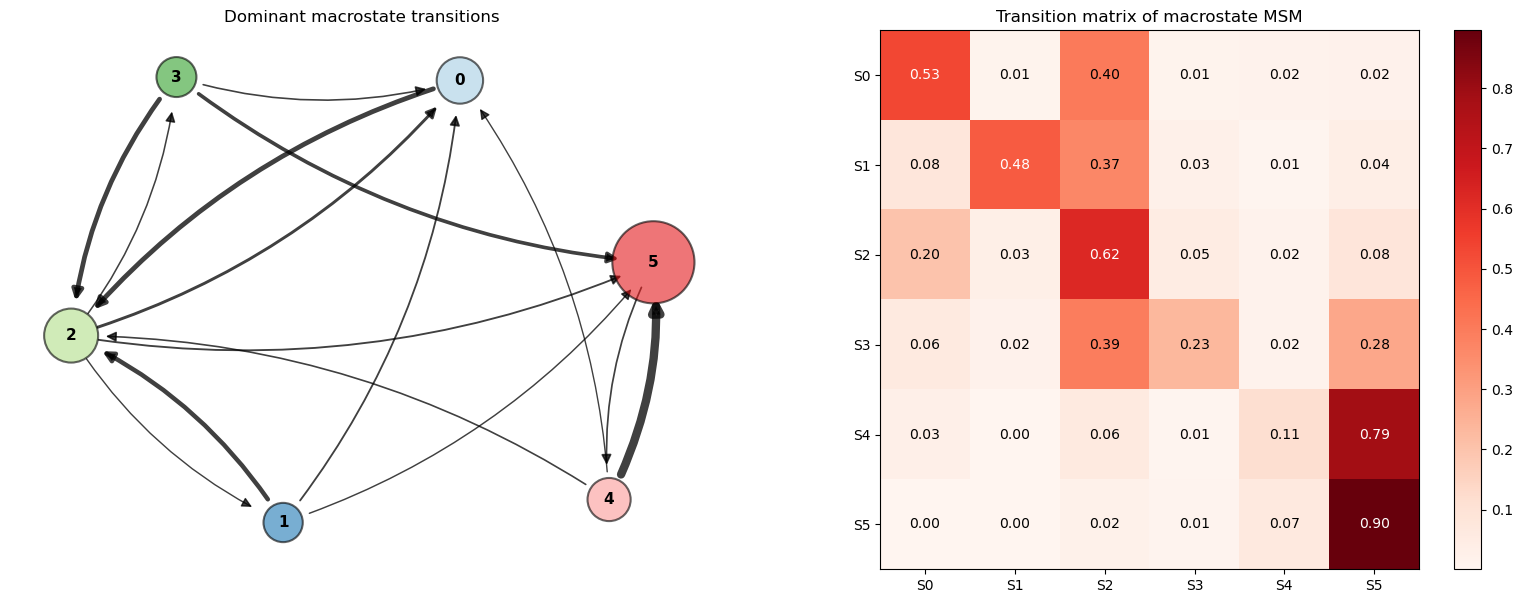

In [14]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (20, 7))

#############################
# graph transition matrix

ax = axs[0]
ax, G_plot, pos = plot_msm_network(
    macro_msm.transition_matrix,
    ax=ax,
    state_colors=macro_color_sequence[:n_macro],
    top_k_per_state=4,
    min_prob=0.03,
    self_edges=False,
    seed=0
)

#############################
T = macro_msm.transition_matrix
im = axs[1].imshow(T, cmap="Reds")
threshold = T.max() / 2

for i in range(T.shape[0]):
    for j in range(T.shape[1]):
        axs[1].text(
            j, i,
            f"{T[i,j]:.2f}",
            ha="center",
            va="center",
            color="white" if T[i,j] > threshold else "black"
        )
fig.colorbar(im, ax=axs[1])

axs[1].set_xticks(np.arange(0, n_macro , 1))
axs[1].set_yticks(np.arange(0, n_macro , 1))
axs[1].set_xticklabels([f"S{i}" for i in range(n_macro)])
axs[1].set_yticklabels([f"S{i}" for i in range(n_macro)])
axs[1].set_title("Transition matrix of macrostate MSM")


plt.show()

#### Reactive flux and mfpt

(<Axes: xlabel='Committor probability'>,
 array([[0.        , 0.63852036],
        [0.37895393, 0.17838202],
        [0.3694704 , 0.7264731 ],
        [0.583716  , 0.        ],
        [0.9186511 , 1.        ],
        [1.        , 0.47178027]], dtype=float32))

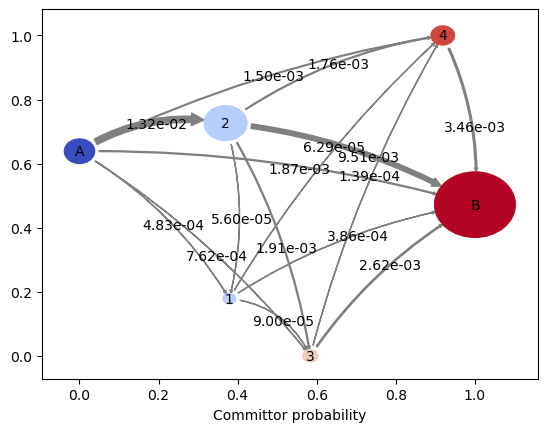

In [23]:
# Automated version

from deeptime.markov import reactive_flux
from deeptime.plots import plot_flux

tpt_results = reactive_flux(transition_matrix = macro_msm.transition_matrix,
                        source_states = [0], #totally unfolded
                        target_states = [5], #fully folded
                        )


plot_flux(flux = tpt_results,
        #state_sizes=None, 
        #flux_scale=1.0, 
        #state_scale=1.0, 
        #state_colors=None,
        #state_labels='auto', 
        #minflux=1e-09, 
        edge_scale=1.5, 
        #edge_curvature=1.0,
        #edge_labels='weights', 
        #edge_label_format='{:.2e}',
        #attribute_to_plot='net_flux',
        #show_committor=True,
        #cmap='coolwarm',
        #ax=None
        )


In [39]:
# Manual version

from deeptime.markov.tools.analysis import committor
from deeptime.markov.tools.flux import flux_matrix


"""
the forward committor gives the probability that a trajectory starting 
in each macrostate will reach the fully folded state (state 5) before 
reaching the totally unfolded state (state 0).
"""
forward_committor = committor(T = macro_msm.transition_matrix, 
                       A = [0], #totally unfolded
                       B = [5], #fully folded
                       forward = True
                       )


print("Forward committor:")
for i, q in enumerate(forward_committor):
    print(f"State {i}: {q:.4f}")

backward_committor = 1 - forward_committor # because detailed balance holds



net_flux_matrix = flux_matrix(
    T = macro_msm.transition_matrix,
    pi = macro_msm.stationary_distribution,
    qminus = backward_committor,
    qplus = forward_committor,
    netflux = True
)

#print("Net flux matrix:\n", net_flux_matrix)

Forward committor:
State 0: 0.0000
State 1: 0.3790
State 2: 0.3695
State 3: 0.5837
State 4: 0.9187
State 5: 1.0000


**TODO** state 1 and state 2 have very similar committor. Try to understand what sets them apart structurally.

In [ ]:
from deeptime.markov.tools.analysis import mfpt

time_frames = mfpt(
                T = macro_msm.transition_matrix,
                target = [5], # fully folded
                origin = [0], # totally unfolded
                tau = macro_msm.lagtime,
                mu = macro_msm.stationary_distribution
            )

print("MFPT from totally unfolded to fully folded")
print("in n. of frames:", time_frames)

frame_to_mus = 300 / macro_traj.shape[0]
print("in n. of microseconds:", time_frames * frame_to_mus)

MFPT from totally unfolded to fully folded
in n. of frames: 12693.465122088895
in n. of microseconds: 2.4953717079860036


Compared to the experimental result (0.73 μs at 360 K for the considered Nle/Nle mutant39), the MD simulation of Piana et al.47 overestimates the overall folding time by a factor 2.5. 


My result overestimates the simulation but it is reasonable, so it's encouraging!

### Pathways decomposition

How deos the protein fold?
- single pathway or parallel pathways?
- are there obligatory intermediate?


The pathway **capacity** is defined as the minimum net flux along the path edges.

The definition is motivated by the fact that the edge with minimum flux acts as a bottleneck for the entire pathway.

It is the natural measure of the importance of a reaction pathway because every trajectory using that channel must traverse every edge on the path, and therefore cannot exceed the weakest edge’s flux.

In [38]:
from deeptime.markov.tools.flux import pathways

from scipy.sparse import csr_matrix
F_sparse = csr_matrix(net_flux_matrix)

(pat, capacities) = pathways.pathways(
                F = F_sparse, 
                A = [0], 
                B = [5]
                #fraction=1.0, 
                #maxiter=1000
                )


sorting_idxs = np.argsort(capacities)[::-1]
pat = [pat[i] for i in sorting_idxs]
capacities = [capacities[i] for i in sorting_idxs]


total_capacity = sum(capacities)

for pat, cap in zip(pat, capacities):
    print(f"Pathway: {pat}, Capacity: {cap:.4f}, Fraction: {cap/total_capacity:.2%}")

Pathway: [0 2 5], Capacity: 0.0095, Fraction: 53.28%
Pathway: [0 2 3 5], Capacity: 0.0019, Fraction: 10.70%
Pathway: [0 5], Capacity: 0.0019, Fraction: 10.48%
Pathway: [0 2 4 5], Capacity: 0.0018, Fraction: 9.84%
Pathway: [0 4 5], Capacity: 0.0015, Fraction: 8.41%
Pathway: [0 3 5], Capacity: 0.0007, Fraction: 3.99%
Pathway: [0 1 5], Capacity: 0.0004, Fraction: 2.16%
Pathway: [0 1 3 4 5], Capacity: 0.0001, Fraction: 0.50%
Pathway: [0 2 1 4 5], Capacity: 0.0001, Fraction: 0.31%
Pathway: [0 3 4 5], Capacity: 0.0000, Fraction: 0.28%
Pathway: [0 1 4 5], Capacity: 0.0000, Fraction: 0.04%


**Comments**

State 2 appears to be a kinetic hub: 75% of the folding flux passes through it. 
The dominant reaction pathway is:

$$
0 \rightarrow 2 \rightarrow 5
$$

accounting for $\simeq 53 \%$ of the total flux.


State 1 is basically irrelevant.

In [40]:
time_from0to2 = mfpt(
                T = macro_msm.transition_matrix,
                target = [2], # dominant intermediate
                origin = [0], # totally unfolded
                tau = macro_msm.lagtime,
                mu = macro_msm.stationary_distribution
            )
print("MFPT from totally unfolded to dominant intermediate")
print("in n. of frames:", time_from0to2)
print("in n. of microseconds:", time_from0to2 * frame_to_mus)


time_from2to5 = mfpt(
                T = macro_msm.transition_matrix,
                target = [5], # fully folded
                origin = [2], # dominant intermediate
                tau = macro_msm.lagtime,
                mu = macro_msm.stationary_distribution
            )

print("MFPT from dominant intermediate to fully folded")
print("in n. of frames:", time_from2to5)
print("in n. of microseconds:", time_from2to5 * frame_to_mus)

MFPT from totally unfolded to dominant intermediate
in n. of frames: 4932.303368144292
in n. of microseconds: 0.9696272973290283
MFPT from dominant intermediate to fully folded
in n. of frames: 11494.191485360432
in n. of microseconds: 2.2596099617298155
